In [1]:
import pandas as pd

# Define the paths to the CSV files
file_paths = [
    r"/content/DOGE-USD From 2017 To Dec-2024.csv",
    r"/content/DOGE-USD From 2017 To Dec-2024.csv",
    r"/content/BTC-USD From 2014 To Dec-2024.csv",
    r"/content/ADA-USD From 2017 To Dec-2024.csv"
]

# Initialize an empty list to store DataFrames
dataframes = []

# Loop through the file paths and read each CSV file
for path in file_paths:
    df = pd.read_csv(path)
    df['Coin'] = path.split('\\')[-1].split(' ')[0]  # Add a 'Coin' column to identify the coin
    dataframes.append(df)

# Combine all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)

# Display the first few rows to check
print(combined_df.head())


                        Date      Open      High       Low     Close  \
0  2017-11-09 00:00:00+00:00  0.001207  0.001415  0.001181  0.001415   
1  2017-11-10 00:00:00+00:00  0.001421  0.001431  0.001125  0.001163   
2  2017-11-11 00:00:00+00:00  0.001146  0.001257  0.001141  0.001201   
3  2017-11-12 00:00:00+00:00  0.001189  0.001210  0.001002  0.001038   
4  2017-11-13 00:00:00+00:00  0.001046  0.001212  0.001019  0.001211   

      Volume               Coin  
0  6259550.0  /content/DOGE-USD  
1  4246520.0  /content/DOGE-USD  
2  2231080.0  /content/DOGE-USD  
3  3288960.0  /content/DOGE-USD  
4  2481270.0  /content/DOGE-USD  


In [2]:
# Check if there are any missing values in the entire dataset
total_missing = combined_df.isnull().sum().sum()

if total_missing > 0:
    print(f"There are {total_missing} missing values in the dataset.")
else:
    print("There are no missing values in the dataset.")

# Apply forward fill to handle missing values
combined_df_ffill = combined_df.fillna(method='ffill')

# Verify the missing values after forward fill
missing_values_ffill = combined_df_ffill.isnull().sum()
print(missing_values_ffill)

# Convert the 'Date' column to datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])

# Set 'Date' as the index of the DataFrame
combined_df.set_index('Date', inplace=True)

# Verify the changes
print(combined_df.head())



There are no missing values in the dataset.
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Coin      0
dtype: int64
                               Open      High       Low     Close     Volume  \
Date                                                                           
2017-11-09 00:00:00+00:00  0.001207  0.001415  0.001181  0.001415  6259550.0   
2017-11-10 00:00:00+00:00  0.001421  0.001431  0.001125  0.001163  4246520.0   
2017-11-11 00:00:00+00:00  0.001146  0.001257  0.001141  0.001201  2231080.0   
2017-11-12 00:00:00+00:00  0.001189  0.001210  0.001002  0.001038  3288960.0   
2017-11-13 00:00:00+00:00  0.001046  0.001212  0.001019  0.001211  2481270.0   

                                        Coin  
Date                                          
2017-11-09 00:00:00+00:00  /content/DOGE-USD  
2017-11-10 00:00:00+00:00  /content/DOGE-USD  
2017-11-11 00:00:00+00:00  /content/DOGE-USD  
2017-11-12 00:00:00+00:00  /content/DOGE-USD  
2017-11-13 00:00

<ipython-input-2-6303599ea8a3>:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df_ffill = combined_df.fillna(method='ffill')


In [3]:
# Summary statistics for the 'Close' column
summary_stats = combined_df['Close'].describe()

# Display the summary statistics
print(summary_stats)


count    11461.000000
mean      6149.826147
std      14886.315780
min          0.001038
25%          0.056591
50%          0.208048
75%        966.724976
max      98997.664060
Name: Close, dtype: float64


In [4]:
#UNIVARIATE VISUALIZATIONS

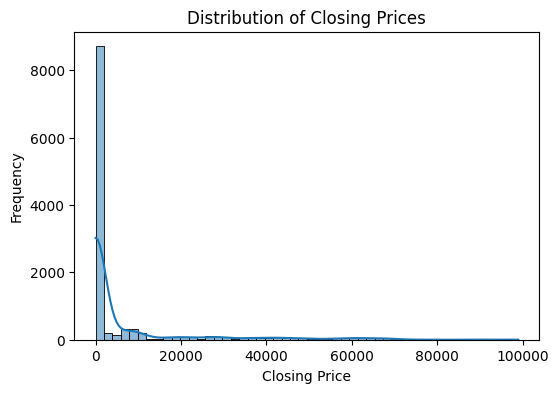

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram for 'Close' prices
plt.figure(figsize=(6, 4))
sns.histplot(combined_df['Close'], bins=50, kde=True)
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()


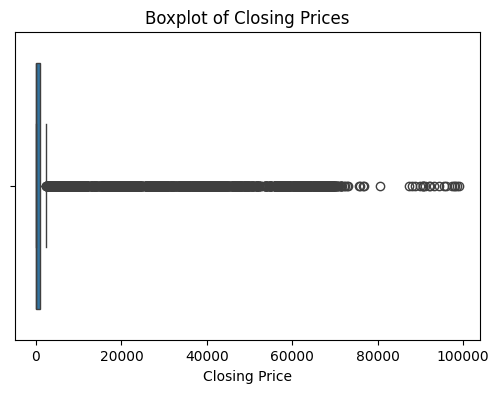

In [8]:
# Plot boxplot for 'Close' prices
plt.figure(figsize=(6, 4))
sns.boxplot(x=combined_df['Close'])
plt.title('Boxplot of Closing Prices')
plt.xlabel('Closing Price')
plt.show()


In [9]:
#BIVARIATE VISUALIZATIONS

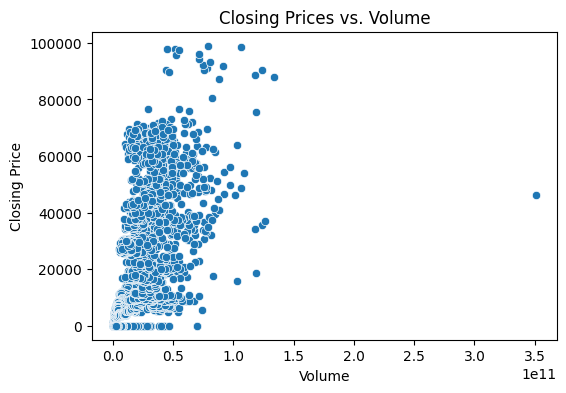

In [12]:
# Scatter plot for 'Close' vs. 'Volume'
plt.figure(figsize=(6, 4))
sns.scatterplot(x=combined_df['Volume'], y=combined_df['Close'])
plt.title('Closing Prices vs. Volume')
plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.show()


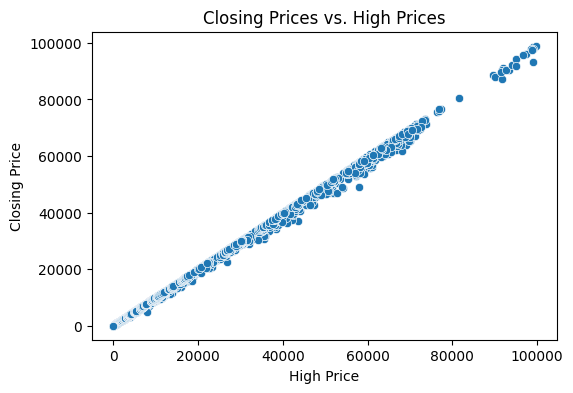

In [13]:
# Scatter plot for 'Close' vs. 'High'
plt.figure(figsize=(6, 4))
sns.scatterplot(x=combined_df['High'], y=combined_df['Close'])
plt.title('Closing Prices vs. High Prices')
plt.xlabel('High Price')
plt.ylabel('Closing Price')
plt.show()


In [14]:
#Data Exploration & Preprocessing done here


In [15]:
#Removing duplicate values for line plot
print(combined_df.index.duplicated().sum())  # Count duplicate dates
combined_df = combined_df[~combined_df.index.duplicated(keep='first')]
combined_df = combined_df.reset_index()  # Reset index if needed


7734


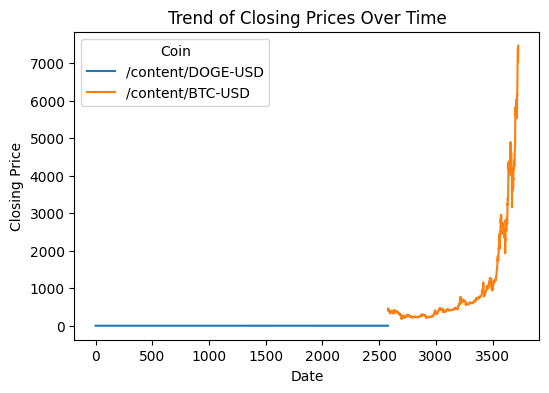

In [18]:
#1. Line Plot for Initial Trend Check
# Line plot of Closing Prices
plt.figure(figsize=(6, 4))
sns.lineplot(data=combined_df, x=combined_df.index, y='Close', hue='Coin')
plt.title('Trend of Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Coin')
plt.show()


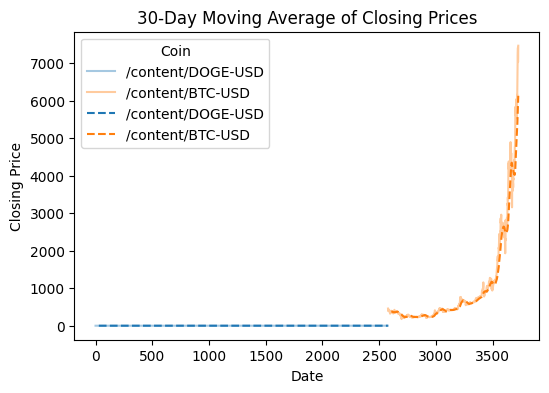

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

window_size = 30  # 30-day moving average
combined_df['Moving_Avg'] = combined_df.groupby('Coin')['Close'].transform(lambda x: x.rolling(window=window_size).mean())

plt.figure(figsize=(6, 4))
sns.lineplot(data=combined_df, x=combined_df.index, y='Close', hue='Coin', alpha=0.4)
sns.lineplot(data=combined_df, x=combined_df.index, y='Moving_Avg', hue='Coin', linestyle='dashed')

plt.title(f'{window_size}-Day Moving Average of Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Coin')
plt.show()


In [22]:
#The graph above shows uptrend as If the closing price is above the moving average.

In [26]:
combined_df['Coin'] = combined_df['Coin'].str.replace('/content/', '', regex=False)
print(combined_df['Coin'].unique())


['DOGE-USD' 'BTC-USD']


In [28]:
file_paths = [
    r"/content/DOGE-USD From 2017 To Dec-2024.csv",
    r"/content/BTC-USD From 2014 To Dec-2024.csv",
    r"/content/ADA-USD From 2017 To Dec-2024.csv",
    r"/content/ETH-USD From 2017 To Dec-2024.csv"  # Missing ETH-USD file added
]


In [29]:
import pandas as pd

# Load all datasets and assign the correct 'Coin' name
dfs = []
for file_path in file_paths:
    df = pd.read_csv(file_path)
    coin_name = file_path.split("/")[-1].split(" ")[0]  # Extract coin name from filename
    df["Coin"] = coin_name
    dfs.append(df)

# Combine into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Verify that all coins are present
print(combined_df['Coin'].unique())  # Should print ['DOGE-USD', 'BTC-USD', 'ADA-USD', 'ETH-USD']


['DOGE-USD' 'BTC-USD' 'ADA-USD' 'ETH-USD']


In [31]:
coin_name = 'BTC-USD'  # or 'DOGE-USD'
coin_data = combined_df[combined_df['Coin'] == coin_name]['Close']
print(coin_data.shape)  # Check if data exists for the selected coin


(3727,)


Decomposition for DOGE-USD


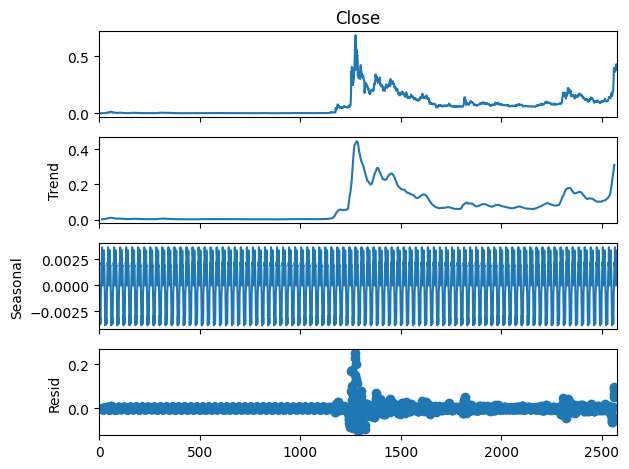

Decomposition for BTC-USD


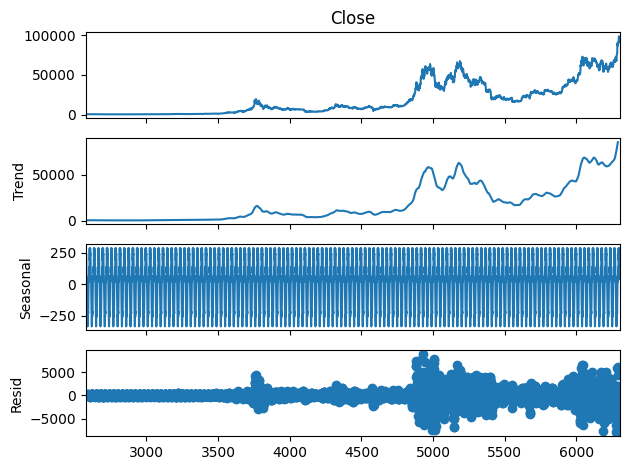

Decomposition for ADA-USD


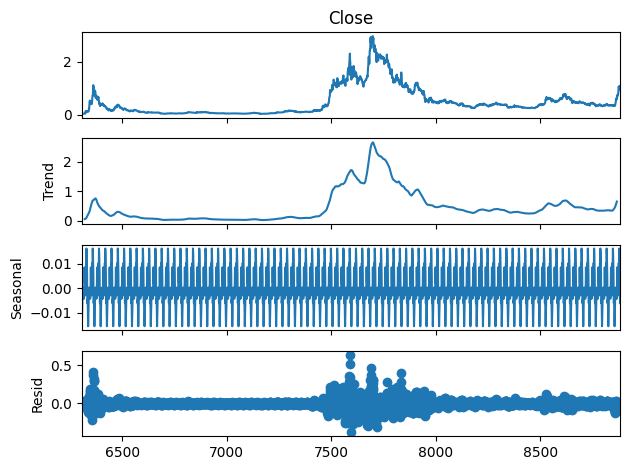

Decomposition for ETH-USD


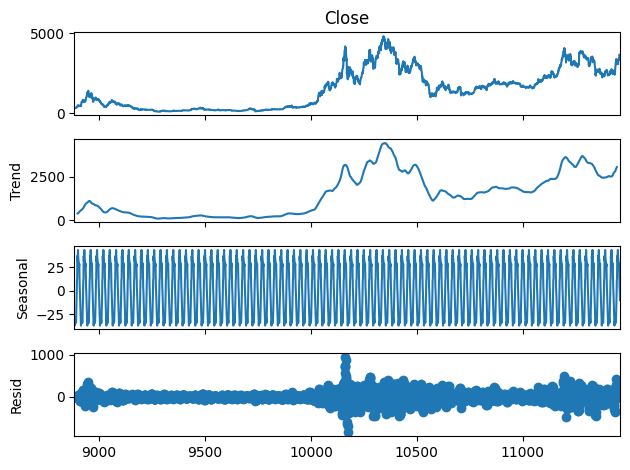

In [33]:
for coin_name in combined_df['Coin'].unique():
    coin_data = combined_df[combined_df['Coin'] == coin_name]['Close']

    if len(coin_data) >= 60:
        print(f"Decomposition for {coin_name}")
        decomposition = seasonal_decompose(coin_data, model='additive', period=30)
        decomposition.plot()
        plt.show()
    else:
        print(f"Not enough data points for {coin_name}")


In [35]:
#The above graph shows how the time series (e.g., crypto prices) is decomposed into its **observed data**, **underlying trend**, **seasonal fluctuations**, and **residual noise**.

In [36]:
print(combined_df.columns)


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Coin', 'Dividends',
       'Stock Splits'],
      dtype='object')


In [37]:
# Make sure 'Close' is numeric
combined_df['Close'] = pd.to_numeric(combined_df['Close'], errors='coerce')

# Calculate IQR
Q1 = combined_df['Close'].quantile(0.25)
Q3 = combined_df['Close'].quantile(0.75)
IQR = Q3 - Q1

# Determine lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
outliers = combined_df[(combined_df['Close'] < lower_bound) | (combined_df['Close'] > upper_bound)]

# Check for outliers
if outliers.empty:
    print("No significant outliers detected.")
else:
    print(f"Found {outliers.shape[0]} outliers.")


Found 1993 outliers.


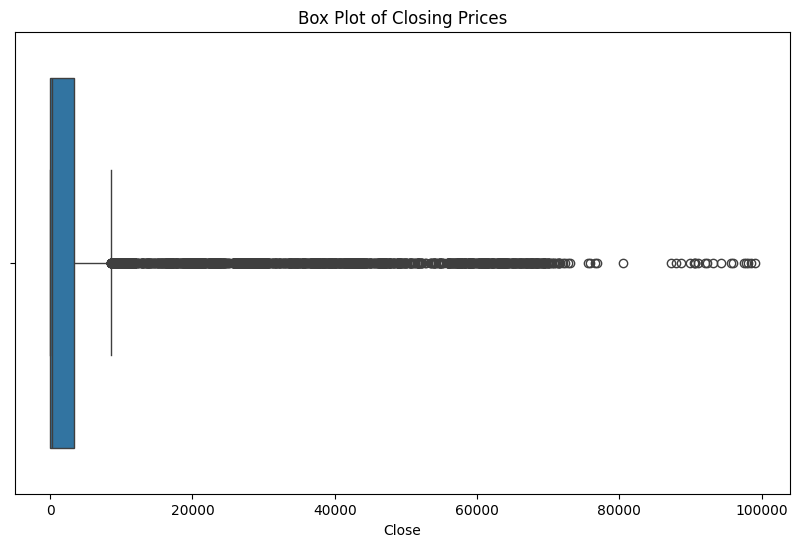

In [38]:
#Visualizing Outliers with Box Plot:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x=combined_df['Close'])
plt.title('Box Plot of Closing Prices')
plt.show()


In [42]:
import numpy as np

# Function to detect outliers in a column based on the 1st and 99th percentiles
def detect_outliers(df, column_name):
    lower_percentile = df[column_name].quantile(0.01)
    upper_percentile = df[column_name].quantile(0.99)

    # Identify outliers: values below lower_percentile or above upper_percentile
    outliers = df[(df[column_name] < lower_percentile) | (df[column_name] > upper_percentile)]

    return outliers, lower_percentile, upper_percentile

# Loop through each column in the DataFrame and check for outliers
for column in combined_df.select_dtypes(include=['float64', 'int64']).columns:  # Only check numeric columns
    outliers, lower_percentile, upper_percentile = detect_outliers(combined_df, column)

    if outliers.shape[0] > 0:  # If there are outliers
        print(f"Outliers detected in column: {column}")
        print(f"Lower percentile (1st): {lower_percentile}")
        print(f"Upper percentile (99th): {upper_percentile}")
        print(f"Number of outliers in {column}: {outliers.shape[0]}")
        print(f"Outlier values:\n{outliers[column].head()}\n")
    else:
        print(f"No outliers detected in column: {column}\n")


Outliers detected in column: Open
Lower percentile (1st): 0.002055
Upper percentile (99th): 66546.07968799994
Number of outliers in Open: 229
Outlier values:
0    0.001207
1    0.001421
2    0.001146
3    0.001189
4    0.001046
Name: Open, dtype: float64

Outliers detected in column: High
Lower percentile (1st): 0.0020886
Upper percentile (99th): 67681.96406599999
Number of outliers in High: 230
Outlier values:
0    0.001415
1    0.001431
2    0.001257
3    0.001210
4    0.001212
Name: High, dtype: float64

Outliers detected in column: Low
Lower percentile (1st): 0.0020193999999999998
Upper percentile (99th): 65116.004692
Number of outliers in Low: 230
Outlier values:
0    0.001181
1    0.001125
2    0.001141
3    0.001002
4    0.001019
Name: Low, dtype: float64

Outliers detected in column: Close
Lower percentile (1st): 0.0020556800000000003
Upper percentile (99th): 66514.09687999995
Number of outliers in Close: 230
Outlier values:
0    0.002055
1    0.002055
2    0.002055
3    0.0020

In [43]:
# Columns that had outliers detected
columns_with_outliers = ['Open', 'High', 'Low', 'Close', 'Volume']

# Apply capping to each of these columns
for column in columns_with_outliers:
    lower_percentile = combined_df[column].quantile(0.01)
    upper_percentile = combined_df[column].quantile(0.99)
    combined_df[column] = np.clip(combined_df[column], lower_percentile, upper_percentile)

# Check summary statistics after capping
print("Summary statistics after capping:")
print(combined_df.describe())


Summary statistics after capping:
               Open          High           Low         Close        Volume  \
count  11461.000000  11461.000000  11461.000000  11461.000000  1.146100e+04   
mean    6406.975764   6551.759273   6251.714092   6412.280266  9.055089e+09   
std    14444.821414  14760.284995  14100.500935  14453.028250  1.346955e+10   
min        0.002055      0.002089      0.002019      0.002056  6.727804e+06   
25%        0.124669      0.129305      0.120876      0.124996  1.726477e+08   
50%      226.440994    230.576996    221.732666    226.391006  1.782070e+09   
75%     3419.726807   3499.370850   3335.021240   3422.049805  1.398903e+10   
max    66546.079688  67681.964066  65116.004692  66514.096880  6.340036e+10   

       Dividends  Stock Splits  
count     2578.0        2578.0  
mean         0.0           0.0  
std          0.0           0.0  
min          0.0           0.0  
25%          0.0           0.0  
50%          0.0           0.0  
75%          0.0       

In [44]:
# Function to detect outliers (after capping or removal)
def detect_outliers(df, column_name):
    lower_percentile = df[column_name].quantile(0.01)
    upper_percentile = df[column_name].quantile(0.99)

    # Identify outliers: values below lower_percentile or above upper_percentile
    outliers = df[(df[column_name] < lower_percentile) | (df[column_name] > upper_percentile)]

    return outliers

# Loop through each column to check outliers left
for column in combined_df.select_dtypes(include=['float64', 'int64']).columns:  # Only check numeric columns
    outliers = detect_outliers(combined_df, column)

    if outliers.shape[0] > 0:  # If there are outliers left
        print(f"Outliers still detected in column: {column}")
        print(f"Number of outliers in {column} after capping/removal: {outliers.shape[0]}")
    else:
        print(f"No outliers detected in column: {column} after capping/removal.")


Outliers still detected in column: Open
Number of outliers in Open after capping/removal: 115
Outliers still detected in column: High
Number of outliers in High after capping/removal: 230
Outliers still detected in column: Low
Number of outliers in Low after capping/removal: 230
Outliers still detected in column: Close
Number of outliers in Close after capping/removal: 230
Outliers still detected in column: Volume
Number of outliers in Volume after capping/removal: 230
No outliers detected in column: Dividends after capping/removal.
No outliers detected in column: Stock Splits after capping/removal.


In [47]:
print(combined_df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Coin', 'Dividends',
       'Stock Splits'],
      dtype='object')


In [50]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(combined_df['Close'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary. Differencing might be needed.")


ADF Statistic: -1.785362690818966
p-value: 0.3877525428515829
The series is not stationary. Differencing might be needed.


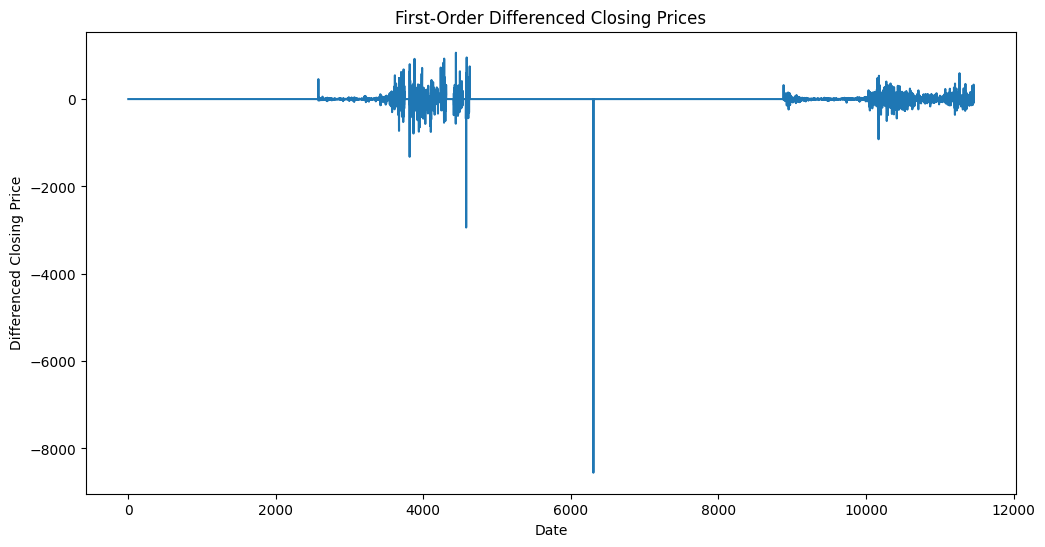

ADF Statistic (First Diff): -29.008664591502292
p-value (First Diff): 0.0
The series is stationary after first differencing.


In [51]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
# First-order differencing to make the data stationary
combined_df['Close_Diff'] = combined_df['Close'].diff()

# Drop the NaN value generated by differencing (first row will have NaN)
combined_df.dropna(subset=['Close_Diff'], inplace=True)

# Plot the differenced series to visually inspect stationarity
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(combined_df['Close_Diff'])
plt.title('First-Order Differenced Closing Prices')
plt.xlabel('Date')
plt.ylabel('Differenced Closing Price')
plt.show()

# Run the ADF test again to confirm stationarity
from statsmodels.tsa.stattools import adfuller
result_diff = adfuller(combined_df['Close_Diff'])
print(f'ADF Statistic (First Diff): {result_diff[0]}')
print(f'p-value (First Diff): {result_diff[1]}')

# Check if the series is stationary after differencing
if result_diff[1] < 0.05:
    print("The series is stationary after first differencing.")
else:
    print("The series is still not stationary.")





In [53]:
print(combined_df.columns)


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Coin', 'Dividends',
       'Stock Splits', 'Close_Diff'],
      dtype='object')


In [54]:
print(combined_df[['Close', 'Close_Diff']].head())


      Close  Close_Diff
2  0.002056         0.0
3  0.002056         0.0
4  0.002056         0.0
5  0.002056         0.0
6  0.002056         0.0


In [55]:
# Convert 'Date' column to datetime format
combined_df['Date'] = pd.to_datetime(combined_df['Date'])

# Check the first few rows to ensure the change
print(combined_df[['Date', 'Close']].head())


                       Date     Close
2 2017-11-11 00:00:00+00:00  0.002056
3 2017-11-12 00:00:00+00:00  0.002056
4 2017-11-13 00:00:00+00:00  0.002056
5 2017-11-14 00:00:00+00:00  0.002056
6 2017-11-15 00:00:00+00:00  0.002056


In [56]:
print(combined_df['Date'].dtype)  # This should return 'datetime64[ns]'


datetime64[ns, UTC]


In [59]:
#Plot time series data to identify trends and seasonality
#Starting with the Line Plot and Moving Average to get a basic understanding.

#then Using STL Decomposition for a more detailed view of trends and seasonality.

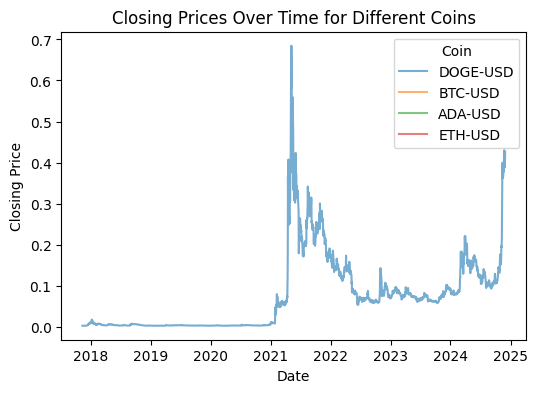

In [64]:
#Line Plot: This shows the overall trend in the data. You can see if there are any large price spikes, dips, or general trends.
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the line plot for closing prices over time for each coin
plt.figure(figsize=(6, 4))
sns.lineplot(data=combined_df, x='Date', y='Close', hue='Coin', alpha=0.6)
plt.title('Closing Prices Over Time for Different Coins')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Coin')
plt.show()


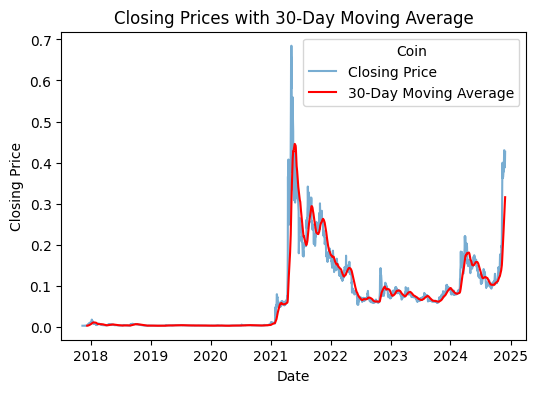

In [65]:
#Moving Average: The 30-day moving average helps smooth out short-term fluctuations and highlights long-term trends.
# Calculate a 30-day moving average for each coin
combined_df['30-Day MA'] = combined_df.groupby('Coin')['Close'].rolling(window=30).mean().reset_index(level=0, drop=True)

# Plot closing prices along with 30-day moving average
plt.figure(figsize=(6, 4))
sns.lineplot(data=combined_df, x='Date', y='Close', label='Closing Price', alpha=0.6)
sns.lineplot(data=combined_df, x='Date', y='30-Day MA', label='30-Day Moving Average', color='red')
plt.title('Closing Prices with 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Coin')
plt.show()


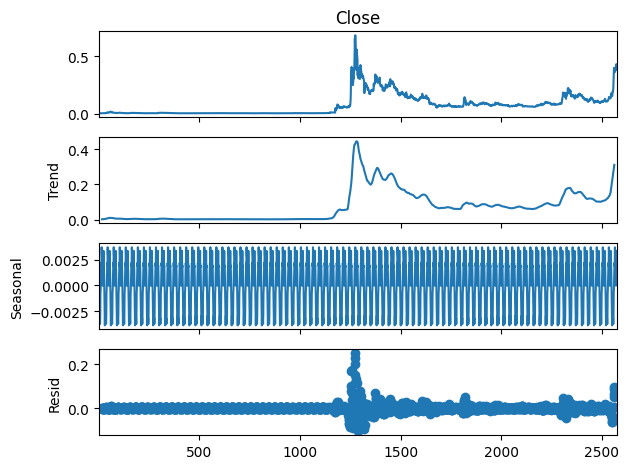

In [66]:
#STL Decomposition: This plot separates the data into three components:
# Trend: The long-term direction of the price (e.g., upward or downward).
# Seasonality: Any regular repeating patterns over time (e.g., monthly or yearly).
# Residuals: The noise or random fluctuations after removing trend and seasonality.
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure that Date is in datetime format and sorted
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df = combined_df.sort_values('Date')

# Select the data for a specific coin (e.g., DOGE-USD) for decomposition
coin_data = combined_df[combined_df['Coin'] == 'DOGE-USD']['Close']

# Decompose the data (additive model) with a period of 30 for monthly seasonality
decomposition = seasonal_decompose(coin_data, model='additive', period=30)

# Plot the decomposed components
decomposition.plot()
plt.show()


In [69]:
from statsmodels.tsa.stattools import adfuller
result_diff = adfuller(combined_df['Close_Diff'])
print(f'ADF Statistic (First Diff): {result_diff[0]}')
print(f'p-value (First Diff): {result_diff[1]}')

# Check if the series is stationary after differencing
if result_diff[1] < 0.05:
    print("The series is stationary after first differencing.")
else:
    print("The series is still not stationary.")

ADF Statistic (First Diff): -7.387690558544282
p-value (First Diff): 8.154679329749764e-11
The series is stationary after first differencing.


In [70]:
# Assuming 'Date' is already set as the index
# Define the split point: Let's say we use 80% for training and 20% for testing
train_size = int(len(combined_df) * 0.8)

# Split the data into training and testing sets
train_data = combined_df[:train_size]
test_data = combined_df[train_size:]

# Verify the split
print(f"Training data size: {train_data.shape[0]}")
print(f"Testing data size: {test_data.shape[0]}")

# Check the first and last few rows of the split datasets
print("\nTraining Data (First 5 rows):")
print(train_data.head())

print("\nTesting Data (Last 5 rows):")
print(test_data.tail())


Training data size: 2060
Testing data size: 516

Training Data (First 5 rows):
                       Date      Open      High       Low     Close  \
2 2017-11-11 00:00:00+00:00  0.002055  0.002089  0.002019  0.002056   
3 2017-11-12 00:00:00+00:00  0.002055  0.002089  0.002019  0.002056   
4 2017-11-13 00:00:00+00:00  0.002055  0.002089  0.002019  0.002056   
5 2017-11-14 00:00:00+00:00  0.002055  0.002089  0.002019  0.002056   
6 2017-11-15 00:00:00+00:00  0.002055  0.002089  0.002019  0.002056   

      Volume      Coin  Dividends  Stock Splits  Close_Diff  30-Day MA  
2  6727804.0  DOGE-USD        0.0           0.0         0.0        NaN  
3  6727804.0  DOGE-USD        0.0           0.0         0.0        NaN  
4  6727804.0  DOGE-USD        0.0           0.0         0.0        NaN  
5  6727804.0  DOGE-USD        0.0           0.0         0.0        NaN  
6  6727804.0  DOGE-USD        0.0           0.0         0.0        NaN  

Testing Data (Last 5 rows):
                          D

In [72]:
#traditional forecasting model:
  #ARIMA/SARIMA (for classical time series forecasting).

#ARIMA (AutoRegressive Integrated Moving Average) is a classical time series model that works well when the data is stationary or can be made stationary by differencing. SARIMA extends ARIMA by adding seasonality components.

# Steps for ARIMA/SARIMA:
# Fit ARIMA model: If the data is not stationary, use differencing to make it stationary.
# Use SARIMA: If there is seasonality, apply SARIMA by setting the seasonal order.



In [82]:
# Split the data correctly and ensure it remains a DataFrame
train_data = combined_df.loc[:len(train_data)-1, ['Date', 'Close']]  # Ensure it includes 'Date'


In [83]:
# Check if train_data is a DataFrame
print(type(train_data))

# Check the first few rows of train_data
print(train_data.head())


<class 'pandas.core.frame.DataFrame'>
                       Date     Close
2 2017-11-11 00:00:00+00:00  0.002056
3 2017-11-12 00:00:00+00:00  0.002056
4 2017-11-13 00:00:00+00:00  0.002056
5 2017-11-14 00:00:00+00:00  0.002056
6 2017-11-15 00:00:00+00:00  0.002056


In [102]:
def create_features(data, lags=5, window=30):
    X = pd.DataFrame()
    for lag in range(1, lags + 1):
        X[f'lag_{lag}'] = data['Close'].shift(lag)
    X['rolling_mean'] = data['Close'].rolling(window=window).mean()
    X['rolling_std'] = data['Close'].rolling(window=window).std()

    # Drop rows with missing values in X
    X = X.dropna()

    # Create y: shift the 'Close' column by -1 and drop NaNs
    y = data['Close'].shift(-1).dropna()

    # Align the indices: take only the common indices between X and y
    common_index = X.index.intersection(y.index)
    X = X.loc[common_index]
    y = y.loc[common_index]

    return X, y

# Create features and target
X, y = create_features(train_data)

# Check the lengths (they should now be the same)
print("Number of samples in X:", len(X))
print("Number of samples in y:", len(y))


Number of samples in X: 70
Number of samples in y: 70


In [103]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%) sets while maintaining time order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 56
Testing samples: 14


In [104]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Initialize the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror')

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error on Test Set:", mse)


Mean Squared Error on Test Set: 0.061529382882094634


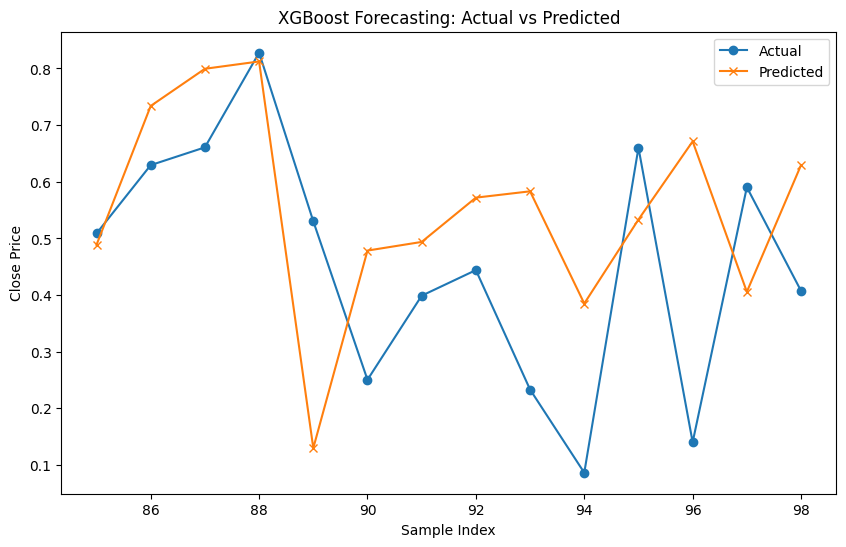

In [105]:
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted', marker='x')
plt.xlabel("Sample Index")
plt.ylabel("Close Price")
plt.title("XGBoost Forecasting: Actual vs Predicted")
plt.legend()
plt.show()


In [106]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared:", r2)


Mean Squared Error (MSE): 0.061529382882094634
Root Mean Squared Error (RMSE): 0.24805116988656722
Mean Absolute Error (MAE): 0.20305374195868048
R-squared: -0.4076359180534348


In [109]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.9 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-1107.096, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1111.099, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1112.114, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1112.075, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1112.838, Time=0.03 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1110.119, Time=0.09 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.528 seconds
Optimal ARIMA Order: (0, 1, 0)
Performing stepwise search to minimize aic


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,1)[12]             : AIC=-1115.204, Time=0.51 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(0,0,1)[12]             : AIC=-1108.404, Time=0.34 sec

Best model:  ARIMA(1,1,0)(0,0,1)[12]          
Total fit time: 11.540 seconds
Optimal SARIMA Order: (1, 1, 0), Seasonal Order: (0, 0, 1, 12)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_

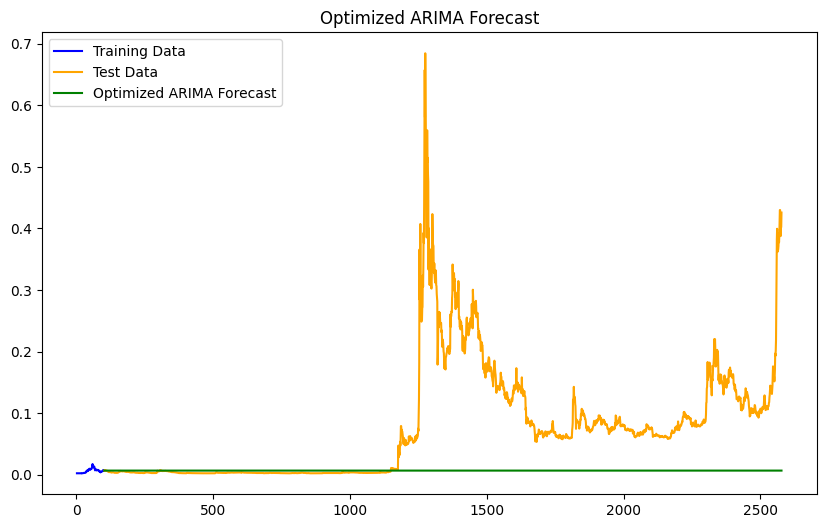

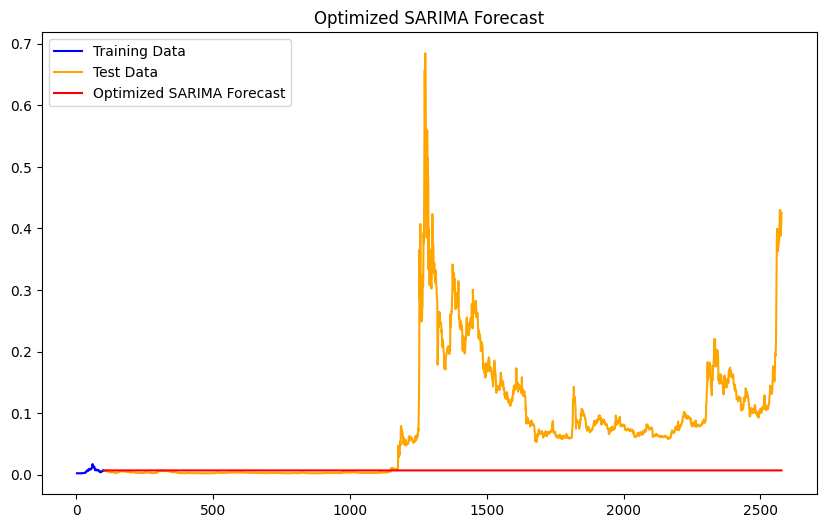


Optimized ARIMA Metrics:
MSE: 0.013440424527863312, RMSE: 0.1159328449054163, MAE: 0.07262578593659128, R²: -0.566880151079538

Optimized SARIMA Metrics:
MSE: 0.013398134564040846, RMSE: 0.11575031129133453, MAE: 0.07257830821243336, R²: -0.561950001383305


In [112]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Select a smaller portion of the training data (first 100 points for speed)
train_data = combined_df[:100]['Close']  # Adjust size for faster testing
test_data = combined_df[100:]['Close']

# ----- Optimizing ARIMA using auto_arima -----
arima_model = auto_arima(train_data, seasonal=False, trace=True,
                         suppress_warnings=True, stepwise=True,
                         max_p=5, max_d=2, max_q=5, max_order=10,
                         n_jobs=-1, maxiter=50)  # Limit maxiter for speed

best_arima_order = arima_model.order  # Best (p,d,q) values
print(f"Optimal ARIMA Order: {best_arima_order}")

# Train optimized ARIMA model
optimized_arima = ARIMA(train_data, order=best_arima_order)
arima_result = optimized_arima.fit()

# Forecasting with ARIMA
forecast_arima = arima_result.forecast(steps=len(test_data))

# ----- Optimizing SARIMA using auto_arima -----
sarima_model = auto_arima(train_data, seasonal=True, m=12, trace=True,
                          suppress_warnings=True, stepwise=True,
                          max_p=3, max_d=1, max_q=3, max_order=5,
                          max_P=3, max_D=1, max_Q=3, max_S=12,
                          n_jobs=-1, maxiter=50)  # Limit maxiter for speed

best_sarima_order = sarima_model.order  # Best (p,d,q)
best_sarima_seasonal_order = sarima_model.seasonal_order  # Best (P,D,Q,S)
print(f"Optimal SARIMA Order: {best_sarima_order}, Seasonal Order: {best_sarima_seasonal_order}")

# Train optimized SARIMA model
optimized_sarima = SARIMAX(train_data, order=best_sarima_order,
                           seasonal_order=best_sarima_seasonal_order)
sarima_result = optimized_sarima.fit()

# Forecasting with SARIMA
forecast_sarima = sarima_result.forecast(steps=len(test_data))

# ----- Plot ARIMA & SARIMA Forecasts -----
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Test Data', color='orange')
plt.plot(test_data.index, forecast_arima, label='Optimized ARIMA Forecast', color='green')
plt.legend(loc='upper left')
plt.title('Optimized ARIMA Forecast')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Test Data', color='orange')
plt.plot(test_data.index, forecast_sarima, label='Optimized SARIMA Forecast', color='red')
plt.legend(loc='upper left')
plt.title('Optimized SARIMA Forecast')
plt.show()

# ----- Model Performance Evaluation -----
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Metrics:")
    print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

# Evaluate ARIMA & SARIMA
evaluate_model(test_data, forecast_arima, "Optimized ARIMA")
evaluate_model(test_data, forecast_sarima, "Optimized SARIMA")


In [113]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------
# Evaluate ARIMA Forecast
# ---------------------------
arima_mse = mean_squared_error(test_data, forecast_arima)
arima_rmse = np.sqrt(arima_mse)
arima_mae = mean_absolute_error(test_data, forecast_arima)
arima_r2 = r2_score(test_data, forecast_arima)

print("ARIMA Performance Metrics:")
print("MSE:", arima_mse)
print("RMSE:", arima_rmse)
print("MAE:", arima_mae)
print("R-squared:", arima_r2)

if arima_r2 > 0.8:
    print("ARIMA predictions are amazing!")
elif arima_r2 > 0.5:
    print("ARIMA predictions are good.")
else:
    print("ARIMA predictions need improvement.")

# ---------------------------
# Evaluate SARIMA Forecast
# ---------------------------
sarima_mse = mean_squared_error(test_data, forecast_sarima)
sarima_rmse = np.sqrt(sarima_mse)
sarima_mae = mean_absolute_error(test_data, forecast_sarima)
sarima_r2 = r2_score(test_data, forecast_sarima)

print("\nSARIMA Performance Metrics:")
print("MSE:", sarima_mse)
print("RMSE:", sarima_rmse)
print("MAE:", sarima_mae)
print("R-squared:", sarima_r2)

if sarima_r2 > 0.8:
    print("SARIMA predictions are amazing!")
elif sarima_r2 > 0.5:
    print("SARIMA predictions are good.")
else:
    print("SARIMA predictions need improvement.")


ARIMA Performance Metrics:
MSE: 0.013440424527863312
RMSE: 0.1159328449054163
MAE: 0.07262578593659128
R-squared: -0.566880151079538
ARIMA predictions need improvement.

SARIMA Performance Metrics:
MSE: 0.013398134564040846
RMSE: 0.11575031129133453
MAE: 0.07257830821243336
R-squared: -0.561950001383305
SARIMA predictions need improvement.


continuing with feature engineering cuz clearly above thing didn't work


In [123]:
import pandas as pd

# Assuming 'combined_df' is your dataset
def add_lag_features(df, lags=5):
    """
    Adds lag features for 'Close' price in the dataset.
    Args:
        df (pd.DataFrame): The original dataset.
        lags (int): The number of lag features to create.
    Returns:
        pd.DataFrame: The dataset with lag features.
    """
    for lag in range(1, lags + 1):
        df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)

    return df

# Apply lag features
combined_df = add_lag_features(combined_df, lags=5)

# Show the first few rows to verify
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,30-Day MA,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_4,Close_Lag_5
2,2017-11-11 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-11-12 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,NaN,0.002056,NaN,NaN,NaN,NaN
4,2017-11-13 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,NaN,0.002056,0.002056,NaN,NaN,NaN
5,2017-11-14 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,NaN,0.002056,0.002056,0.002056,NaN,NaN
6,2017-11-15 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,NaN,0.002056,0.002056,0.002056,0.002056,NaN


In [124]:
def add_rolling_features(df, windows=[7, 14, 30]):
    """
    Adds rolling mean and rolling standard deviation for the 'Close' price.
    Args:
        df (pd.DataFrame): The original dataset.
        windows (list): List of window sizes for rolling statistics.
    Returns:
        pd.DataFrame: The dataset with rolling features.
    """
    for window in windows:
        df[f'Rolling_Mean_{window}'] = df['Close'].rolling(window=window).mean()
        df[f'Rolling_Std_{window}'] = df['Close'].rolling(window=window).std()

    return df

# Apply rolling features
combined_df = add_rolling_features(combined_df, windows=[7, 14, 30])

# Show the first few rows to verify
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,Close_Lag_2,Close_Lag_3,Close_Lag_4,Close_Lag_5,Rolling_Mean_7,Rolling_Std_7,Rolling_Mean_14,Rolling_Std_14,Rolling_Mean_30,Rolling_Std_30
2,2017-11-11 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-11-12 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-11-13 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,0.002056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-11-14 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,0.002056,0.002056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017-11-15 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,0.002056,0.002056,0.002056,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
def add_ema_features(df, windows=[7, 14, 30]):
    """
    Adds Exponential Moving Averages (EMA) for the 'Close' price.
    Args:
        df (pd.DataFrame): The original dataset.
        windows (list): List of window sizes for EMA.
    Returns:
        pd.DataFrame: The dataset with EMA features.
    """
    for window in windows:
        df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()

    return df

# Apply EMA features
combined_df = add_ema_features(combined_df, windows=[7, 14, 30])

# Show the first few rows to verify
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,Close_Lag_5,Rolling_Mean_7,Rolling_Std_7,Rolling_Mean_14,Rolling_Std_14,Rolling_Mean_30,Rolling_Std_30,EMA_7,EMA_14,EMA_30
2,2017-11-11 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056
3,2017-11-12 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056
4,2017-11-13 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056
5,2017-11-14 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056
6,2017-11-15 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056


In [128]:
def add_time_based_features(df):
    """
    Adds time-based features like 'Month', 'Weekday', and 'Year'.
    Args:
        df (pd.DataFrame): The original dataset.
    Returns:
        pd.DataFrame: The dataset with time-based features.
    """
    df['Month'] = df['Date'].dt.month
    df['Weekday'] = df['Date'].dt.weekday
    df['Year'] = df['Date'].dt.year
    return df

# Assuming 'Date' is a datetime column
combined_df['Date'] = pd.to_datetime(combined_df['Date'])  # Ensure it's a datetime column
combined_df = add_time_based_features(combined_df)

# Show the first few rows to verify
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,Rolling_Mean_14,Rolling_Std_14,Rolling_Mean_30,Rolling_Std_30,EMA_7,EMA_14,EMA_30,Month,Weekday,Year
2,2017-11-11 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056,11,5,2017
3,2017-11-12 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056,11,6,2017
4,2017-11-13 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056,11,0,2017
5,2017-11-14 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056,11,1,2017
6,2017-11-15 00:00:00+00:00,0.002055,0.002089,0.002019,0.002056,6727804.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.002056,0.002056,0.002056,11,2,2017


In [129]:
from sklearn.preprocessing import MinMaxScaler

def scale_features(df, features):
    """
    Scales the selected features using Min-Max Scaling.
    Args:
        df (pd.DataFrame): The dataset.
        features (list): List of feature names to scale.
    Returns:
        pd.DataFrame: The dataset with scaled features.
    """
    scaler = MinMaxScaler()
    df[features] = scaler.fit_transform(df[features])
    return df

# Select the features to scale (you can choose the relevant ones)
numeric_features = [
    'Close', 'Volume', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Rolling_Std_14', 'Rolling_Mean_30', 'Rolling_Std_30',
    'EMA_7', 'EMA_14', 'EMA_30', 'Month', 'Weekday', 'Year'
]

# Apply scaling
combined_df = scale_features(combined_df, numeric_features)

# Show the first few rows to verify
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,Rolling_Mean_14,Rolling_Std_14,Rolling_Mean_30,Rolling_Std_30,EMA_7,EMA_14,EMA_30,Month,Weekday,Year
2,2017-11-11 00:00:00+00:00,0.002055,0.002089,0.002019,0.0,0.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.909091,0.833333,0.0
3,2017-11-12 00:00:00+00:00,0.002055,0.002089,0.002019,0.0,0.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.909091,1.000000,0.0
4,2017-11-13 00:00:00+00:00,0.002055,0.002089,0.002019,0.0,0.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.909091,0.000000,0.0
5,2017-11-14 00:00:00+00:00,0.002055,0.002089,0.002019,0.0,0.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.909091,0.166667,0.0
6,2017-11-15 00:00:00+00:00,0.002055,0.002089,0.002019,0.0,0.0,DOGE-USD,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.909091,0.333333,0.0


In [130]:
from sklearn.model_selection import train_test_split

# Create the target variable 'y' (next day's Close price)
combined_df['Target'] = combined_df['Close'].shift(-1)

# Drop rows with NaN values (the last row will have NaN for 'Target')
combined_df = combined_df.dropna()

# Define features (X) and target (y)
features = [
    'Close', 'Volume', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Rolling_Std_14', 'Rolling_Mean_30', 'Rolling_Std_30',
    'EMA_7', 'EMA_14', 'EMA_30', 'Month', 'Weekday', 'Year'
]
X = combined_df[features]
y = combined_df['Target']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Show the first few rows of the split data
X_train.head(), y_train.head()


(       Close    Volume  Close_Lag_1  Close_Lag_2  Close_Lag_3  Close_Lag_4  \
 31  0.000720  0.000000     0.000822     0.001059     0.000973     0.000890   
 32  0.001087  0.000005     0.000720     0.000822     0.001059     0.000973   
 33  0.001828  0.000197     0.001087     0.000720     0.000822     0.001059   
 34  0.002058  0.000385     0.001828     0.001087     0.000720     0.000822   
 35  0.002422  0.000263     0.002058     0.001828     0.001087     0.000720   
 
     Close_Lag_5  Rolling_Mean_7  Rolling_Std_7  Rolling_Mean_14  \
 31     0.000620        0.000944       0.000963         0.000609   
 32     0.000890        0.001026       0.000951         0.000707   
 33     0.000973        0.001227       0.002002         0.000832   
 34     0.001059        0.001421       0.002819         0.001016   
 35     0.000822        0.001662       0.003654         0.001232   
 
     Rolling_Std_14  Rolling_Mean_30  Rolling_Std_30     EMA_7    EMA_14  \
 31        0.001661         0.000346  

In [131]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Convert the data into DMatrix format (XGBoost's internal format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters for XGBoost
params = {
    'objective': 'reg:squarederror',  # Regression task
    'max_depth': 6,  # Depth of the tree
    'learning_rate': 0.1,  # Step size
    'n_estimators': 100,  # Number of boosting rounds
    'eval_metric': 'rmse'  # Use RMSE as the evaluation metric
}

# Train the model
model = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions
y_pred = model.predict(dtest)

# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Show the evaluation metrics
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:02:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


Mean Squared Error: 0.00030033864993666307
R-squared: 0.9678037758856247


In [134]:
!pip install --upgrade scikit-learn xgboost

In [138]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming 'combined_df' is your dataset with features and target (Close price)

# Remove non-numeric columns (e.g., 'Date', 'Coin')
X = combined_df.drop(['Close', 'Date', 'Coin'], axis=1)  # Features (excluding Close, Date, Coin)
y = combined_df['Close']  # Target variable (Close price)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Convert data to DMatrix format (XGBoost's internal format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define hyperparameters and cross-validation setup
param = {
    'objective': 'reg:squarederror',  # Regression task
    'eval_metric': 'rmse',  # RMSE evaluation metric
    'max_depth': 6,  # Depth of tree
    'learning_rate': 0.1,  # Step size
    'subsample': 0.8,  # Fraction of samples
    'colsample_bytree': 0.8  # Fraction of features
}

# Perform cross-validation
cv_results = xgb.cv(
    param, dtrain, num_boost_round=1000, nfold=5,
    early_stopping_rounds=10, seed=42, verbose_eval=10
)

# Print the results of the cross-validation
print(cv_results)


[0]	train-rmse:0.12498+0.00165	test-rmse:0.12510+0.00673
[10]	train-rmse:0.04687+0.00065	test-rmse:0.04828+0.00516
[20]	train-rmse:0.01849+0.00043	test-rmse:0.02197+0.00450
[30]	train-rmse:0.00803+0.00032	test-rmse:0.01325+0.00390
[40]	train-rmse:0.00397+0.00015	test-rmse:0.01055+0.00352
[50]	train-rmse:0.00232+0.00010	test-rmse:0.00949+0.00316
[60]	train-rmse:0.00158+0.00007	test-rmse:0.00904+0.00290
[70]	train-rmse:0.00119+0.00005	test-rmse:0.00877+0.00280
[80]	train-rmse:0.00096+0.00004	test-rmse:0.00863+0.00274
[90]	train-rmse:0.00082+0.00004	test-rmse:0.00858+0.00271
[100]	train-rmse:0.00073+0.00003	test-rmse:0.00853+0.00266
[110]	train-rmse:0.00065+0.00003	test-rmse:0.00850+0.00264
[120]	train-rmse:0.00059+0.00003	test-rmse:0.00848+0.00263
[130]	train-rmse:0.00054+0.00003	test-rmse:0.00846+0.00262
[140]	train-rmse:0.00050+0.00002	test-rmse:0.00846+0.00262
[150]	train-rmse:0.00048+0.00001	test-rmse:0.00845+0.00262
[160]	train-rmse:0.00047+0.00002	test-rmse:0.00845+0.00261
[170]	tr

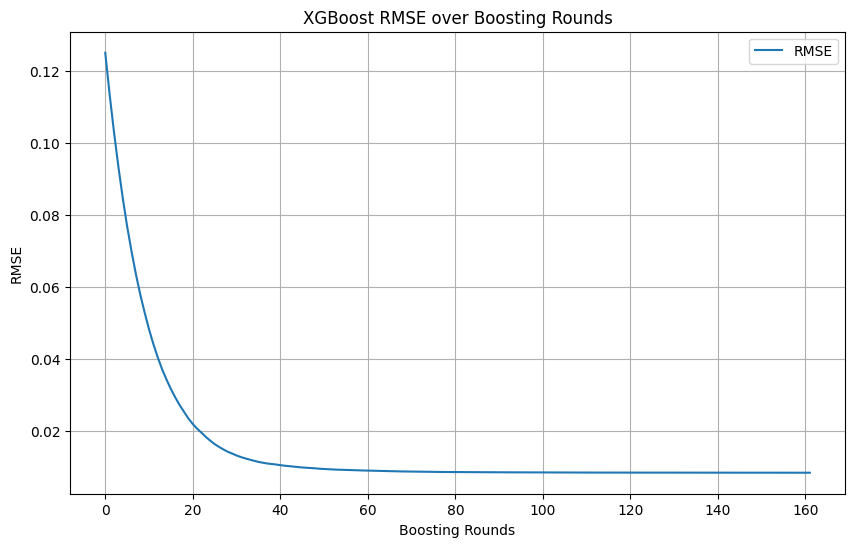

In [139]:
import matplotlib.pyplot as plt

# Get the RMSE values from the cross-validation results
rmse_results = cv_results['test-rmse-mean']

# Plot the RMSE across the boosting rounds
plt.figure(figsize=(10,6))
plt.plot(rmse_results, label='RMSE')
plt.title('XGBoost RMSE over Boosting Rounds')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()


In [140]:
# Extract the best boosting round (from early stopping)
best_num_boost_round = cv_results.shape[0] - cv_results['test-rmse-mean'].idxmin()

# Final model training with optimal number of boosting rounds
final_model = xgb.train(param, dtrain, num_boost_round=best_num_boost_round)

# Make predictions on the test set
y_pred = final_model.predict(dtest)

# Evaluate the model's performance on the test set
from sklearn.metrics import mean_squared_error, r2_score

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Final Model RMSE: {rmse}")
print(f"Final Model R-squared: {r2}")


Final Model RMSE: 0.11242996447510578
Final Model R-squared: -0.41372490865711953


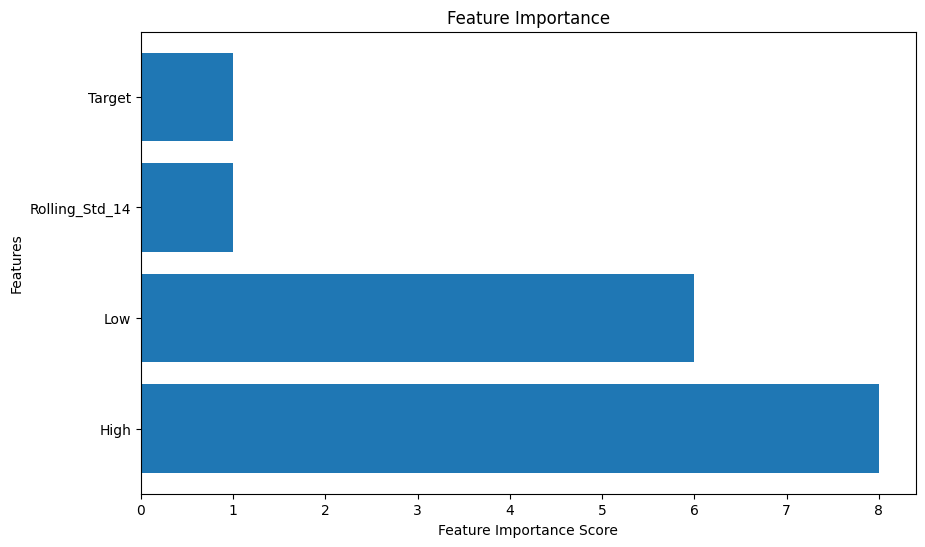

In [141]:
# Plotting feature importance
import matplotlib.pyplot as plt

# Get the feature importance from the final model
feature_importance = final_model.get_score(importance_type='weight')

# Sort the features based on importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

# Extract feature names and scores
features, scores = zip(*sorted_features)

# Plot the feature importance
plt.figure(figsize=(10,6))
plt.barh(features, scores)
plt.title('Feature Importance')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()


In [142]:
# Define a more refined set of hyperparameters
param_refined = {
    'objective': 'reg:squarederror',  # Regression task
    'eval_metric': 'rmse',  # RMSE evaluation metric
    'max_depth': [3, 4, 5, 6],  # Experiment with shallower trees
    'learning_rate': [0.01, 0.05, 0.1],  # Try lower learning rate
    'subsample': [0.6, 0.7, 0.8],  # Fraction of samples
    'colsample_bytree': [0.6, 0.7, 0.8]  # Fraction of features
}

# Try using RandomizedSearchCV or XGBoost's cv method again for a more refined search


In [143]:
# Add more lag features (up to 10)
combined_df = add_lag_features(combined_df, lags=10)

# Show updated dataset
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,EMA_30,Month,Weekday,Year,Target,Close_Lag_6,Close_Lag_7,Close_Lag_8,Close_Lag_9,Close_Lag_10
31,2017-12-10 00:00:00+00:00,0.002607,0.002742,0.002307,0.000720,0.000000,DOGE-USD,0.0,0.0,-0.000070,...,0.000554,1.0,1.000000,0.0,0.001087,NaN,NaN,NaN,NaN,NaN
32,2017-12-11 00:00:00+00:00,0.002563,0.002894,0.002534,0.001087,0.000005,DOGE-USD,0.0,0.0,0.000251,...,0.000632,1.0,0.000000,0.0,0.001828,NaN,NaN,NaN,NaN,NaN
33,2017-12-12 00:00:00+00:00,0.002794,0.003381,0.002665,0.001828,0.000197,DOGE-USD,0.0,0.0,0.000506,...,0.000782,1.0,0.166667,0.0,0.002058,NaN,NaN,NaN,NaN,NaN
34,2017-12-13 00:00:00+00:00,0.003306,0.003884,0.003218,0.002058,0.000385,DOGE-USD,0.0,0.0,0.000157,...,0.000947,1.0,0.333333,0.0,0.002422,NaN,NaN,NaN,NaN,NaN
35,2017-12-14 00:00:00+00:00,0.003449,0.003718,0.003419,0.002422,0.000263,DOGE-USD,0.0,0.0,0.000248,...,0.001139,1.0,0.500000,0.0,0.002499,NaN,NaN,NaN,NaN,NaN


In [144]:
# Adding additional rolling statistics (mean, median, max)
combined_df['Rolling_Mean_10'] = combined_df['Close'].rolling(window=10).mean()
combined_df['Rolling_Median_10'] = combined_df['Close'].rolling(window=10).median()
combined_df['Rolling_Max_10'] = combined_df['Close'].rolling(window=10).max()

# Drop rows with NaN values created by rolling statistics
combined_df.dropna(inplace=True)


In [145]:
# Add more lag features (up to 10)
combined_df = add_lag_features(combined_df, lags=10)

# Show the updated dataset
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,Year,Target,Close_Lag_6,Close_Lag_7,Close_Lag_8,Close_Lag_9,Close_Lag_10,Rolling_Mean_10,Rolling_Median_10,Rolling_Max_10
41,2017-12-20 00:00:00+00:00,0.005619,0.007067,0.004892,0.006746,0.000964,DOGE-USD,0.0,0.0,0.000995,...,0.0,0.007865,NaN,NaN,NaN,NaN,NaN,0.003977,0.003894,0.006746
42,2017-12-21 00:00:00+00:00,0.006733,0.008768,0.006583,0.007865,0.002404,DOGE-USD,0.0,0.0,0.000764,...,0.0,0.005856,NaN,NaN,NaN,NaN,NaN,0.004655,0.005484,0.007865
43,2017-12-22 00:00:00+00:00,0.007386,0.007625,0.004742,0.005856,0.000899,DOGE-USD,0.0,0.0,-0.001371,...,0.0,0.007621,NaN,NaN,NaN,NaN,NaN,0.005058,0.005717,0.007865
44,2017-12-23 00:00:00+00:00,0.006135,0.008076,0.006110,0.007621,0.001000,DOGE-USD,0.0,0.0,0.001205,...,0.0,0.009559,NaN,NaN,NaN,NaN,NaN,0.005614,0.005805,0.007865
45,2017-12-24 00:00:00+00:00,0.007282,0.008948,0.005974,0.009559,0.002162,DOGE-USD,0.0,0.0,0.001323,...,0.0,0.010070,NaN,NaN,NaN,NaN,NaN,0.006328,0.006134,0.009559


In [146]:
# Adding additional rolling statistics (mean, median, max)
combined_df['Rolling_Mean_10'] = combined_df['Close'].rolling(window=10).mean()
combined_df['Rolling_Median_10'] = combined_df['Close'].rolling(window=10).median()
combined_df['Rolling_Max_10'] = combined_df['Close'].rolling(window=10).max()

# Drop rows with NaN values created by rolling statistics
combined_df.dropna(inplace=True)

# Show the updated dataset
combined_df.head()


,Date,Open,High,Low,Close,Volume,Coin,Dividends,Stock Splits,Close_Diff,...,Year,Target,Close_Lag_6,Close_Lag_7,Close_Lag_8,Close_Lag_9,Close_Lag_10,Rolling_Mean_10,Rolling_Median_10,Rolling_Max_10
51,2017-12-30 00:00:00+00:00,0.009365,0.009446,0.007388,0.008502,0.000780,DOGE-USD,0.0,0.0,-0.001531,...,0.000000,0.010131,0.009559,0.007621,0.005856,0.007865,0.006746,0.009039,0.009489,0.010774
52,2017-12-31 00:00:00+00:00,0.007803,0.009274,0.007669,0.010131,0.000876,DOGE-USD,0.0,0.0,0.001112,...,0.000000,0.010038,0.010070,0.009559,0.007621,0.005856,0.007865,0.009266,0.009772,0.010774
53,2018-01-01 00:00:00+00:00,0.009031,0.009063,0.008101,0.010038,0.000692,DOGE-USD,0.0,0.0,-0.000063,...,0.142857,0.010384,0.010774,0.010070,0.009559,0.007621,0.005856,0.009684,0.010011,0.010774
54,2018-01-02 00:00:00+00:00,0.008873,0.009598,0.008551,0.010384,0.001304,DOGE-USD,0.0,0.0,0.000236,...,0.142857,0.010640,0.009984,0.010774,0.010070,0.009559,0.007621,0.009960,0.010054,0.010774
55,2018-01-03 00:00:00+00:00,0.009088,0.009584,0.008882,0.010640,0.000941,DOGE-USD,0.0,0.0,0.000175,...,0.142857,0.011115,0.009419,0.009984,0.010774,0.010070,0.009559,0.010069,0.010100,0.010774


In [147]:
# Remove non-numeric columns and split data
X = combined_df.drop(['Close', 'Date', 'Coin'], axis=1)  # Features
y = combined_df['Close']  # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Convert data to DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train the model again (you can keep the same parameters for now)
final_model = xgb.train(param, dtrain, num_boost_round=1000)

# Make predictions on the test set
y_pred = final_model.predict(dtest)

# Evaluate the model's performance on the test set
from sklearn.metrics import mean_squared_error, r2_score

# Calculate RMSE and R-squared
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Final Model RMSE: {rmse}")
print(f"Final Model R-squared: {r2}")


Final Model RMSE: 0.005972700001542931
Final Model R-squared: 0.9960209810148464


In [150]:
# Get the feature names used during training
feature_names = dtrain.feature_names
print(feature_names)


['Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits', 'Close_Diff', '30-Day MA', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5', 'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Rolling_Std_14', 'Rolling_Mean_30', 'Rolling_Std_30', 'EMA_7', 'EMA_14', 'EMA_30', 'Month', 'Weekday', 'Year', 'Target', 'Close_Lag_6', 'Close_Lag_7', 'Close_Lag_8', 'Close_Lag_9', 'Close_Lag_10', 'Rolling_Mean_10', 'Rolling_Median_10', 'Rolling_Max_10']


In [151]:
# Example of custom input with the correct feature names
custom_input_full = {
    'Open': 1.6,
    'High': 1.7,
    'Low': 1.5,
    'Volume': 10000,
    'Dividends': 0,
    'Stock Splits': 0,
    'Close_Diff': 0.02,  # Example value
    '30-Day MA': 1.55,    # Example value
    'Close_Lag_1': 1.5,
    'Close_Lag_2': 1.55,
    'Close_Lag_3': 1.52,
    'Close_Lag_4': 1.49,
    'Close_Lag_5': 1.47,
    'Close_Lag_6': 1.48,
    'Close_Lag_7': 1.50,
    'Close_Lag_8': 1.51,
    'Close_Lag_9': 1.52,
    'Close_Lag_10': 1.53,
    'Rolling_Mean_7': 1.51,
    'Rolling_Std_7': 0.02,
    'Rolling_Mean_14': 1.50,
    'Rolling_Std_14': 0.02,
    'Rolling_Mean_30': 1.49,
    'Rolling_Std_30': 0.03,
    'EMA_7': 1.51,
    'EMA_14': 1.52,
    'EMA_30': 1.53,
    'Month': 2,
    'Weekday': 3,
    'Year': 2025,
    'Target': 1.50,  # Target is an example value
    'Rolling_Mean_10': 1.52,
    'Rolling_Median_10': 1.51,
    'Rolling_Max_10': 1.53
}

# Convert the custom input to a DataFrame (same structure as the training data)
custom_input_df = pd.DataFrame([custom_input_full])

# Ensure the order of columns matches the training data's feature names
custom_input_df = custom_input_df[feature_names]

# Convert the input to DMatrix (XGBoost format)
custom_input_dmatrix = xgb.DMatrix(custom_input_df)

# Predict using the trained model
predicted_value = final_model.predict(custom_input_dmatrix)

# Print the predicted value
print(f"Predicted Close Price: {predicted_value[0]}")


Predicted Close Price: 0.820703387260437
